In [1]:
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. FUNZIONI BASE PER IL PROBLEMA (P1)
# ==========================================

def compute_loss(w, X, y, lam):
    """
    Calcola il valore della funzione obiettivo f(w).
    Nessun uso di numpy.linalg.norm, solo operazioni elementari.
    """
    # 1. Calcolo del residuo: (X^T * w) - y
    # X.T è (n, m), w è (m,) -> il risultato è un vettore (n,)
    residual = (X.T @ w) - y

    # 2. Somma dei quadrati diviso 2
    loss_data = 0.5 * np.sum(residual**2)

    # 3. Termine di regolarizzazione: 1/2 * lambda^2 * ||w||^2
    loss_reg = 0.5 * (lam**2) * np.sum(w**2)

    return loss_data + loss_reg

def compute_gradient(w, X, y, lam):
    """
    Calcola il vettore gradiente di f(w) rispetto a w.
    """
    # 1. Residuo: (X^T * w) - y  (dimensione n)
    residual = (X.T @ w) - y

    # 2. Moltiplicazione per X: X * residuo (dimensione m)
    grad_data = X @ residual

    # 3. Gradiente della regolarizzazione (dimensione m)
    grad_reg = (lam**2) * w

    return grad_data + grad_reg


# ==========================================
# 2. FUNZIONE DI TESTING "DA ZERO"
# ==========================================

def check_gradient(w, X, y, lam, eps=1e-7):
    """
    Verifica che il gradiente analitico sia corretto calcolando
    la derivata numerica tramite differenze finite centrali.
    Formula: f'(x) approx (f(x + eps) - f(x - eps)) / (2 * eps)
    Non usa scipy!
    """
    m = len(w)
    grad_approx = np.zeros(m)

    print("Calcolo del gradiente numerico in corso (potrebbe richiedere qualche secondo)...")

    for i in range(m):
        # Perturbazione in avanti
        w_plus = w.copy()
        w_plus[i] += eps
        loss_plus = compute_loss(w_plus, X, y, lam)

        # Perturbazione all'indietro
        w_minus = w.copy()
        w_minus[i] -= eps
        loss_minus = compute_loss(w_minus, X, y, lam)

        # Derivata parziale i-esima
        grad_approx[i] = (loss_plus - loss_minus) / (2 * eps)

    # Calcolo il gradiente analitico con la nostra funzione
    grad_analytic = compute_gradient(w, X, y, lam)

    # Calcolo l'errore (distanza euclidea) senza usare np.linalg.norm
    diff_vector = grad_approx - grad_analytic
    error = np.sqrt(np.sum(diff_vector**2))

    return error


In [3]:
# ==========================================
# 3. ESECUZIONE DEL TEST
# ==========================================
if __name__ == "__main__":
    # Creiamo un piccolo dataset dummy per testare la matematica
    np.random.seed(42)
    m_test = 50  # righe (tall)
    n_test = 10  # colonne (thin)
    lam_test = 0.5

    X_test = np.random.randn(m_test, n_test)
    y_test = np.random.randn(n_test)
    w_test = np.random.randn(m_test)

    print(f"Test su dimensioni: X={X_test.shape}, w={w_test.shape}, y={y_test.shape}")

    # Test Funzione Obiettivo
    loss_val = compute_loss(w_test, X_test, y_test, lam_test)
    print(f"Valore f(w): {loss_val:.4f}")

    # Test Gradiente
    error = check_gradient(w_test, X_test, y_test, lam_test)

    print("-" * 40)
    print(f"Errore tra gradiente analitico e numerico: {error:.2e}")
    if error < 1e-5:
        print("✅ SUCCESSO! Il tuo gradiente è matematicamente perfetto.")
    else:
        print("❌ ERRORE! Rivedi le formule del gradiente.")

Test su dimensioni: X=(50, 10), w=(50,), y=(10,)
Valore f(w): 130.2183
Calcolo del gradiente numerico in corso (potrebbe richiedere qualche secondo)...
----------------------------------------
Errore tra gradiente analitico e numerico: 8.88e-07
✅ SUCCESSO! Il tuo gradiente è matematicamente perfetto.


In [4]:
import pandas as pd
import numpy as np
import time

# ==========================================
# 1. FUNZIONI RIGOROSE (P1)
# ==========================================
# def compute_loss(w, X, y, lam):
#     residual = (X.T @ w) - y
#     loss_data = 0.5 * np.sum(residual**2)
#     loss_reg = 0.5 * (lam**2) * np.sum(w**2)
#     return loss_data + loss_reg
#
# def compute_gradient(w, X, y, lam):
#     residual = (X.T @ w) - y
#     grad_data = X @ residual
#     grad_reg = (lam**2) * w
#     return grad_data + grad_reg

# ==========================================
# 2. PREPROCESSING ML-CUP
# ==========================================
def load_and_preprocess_data(filepath, seed=42):
    df = pd.read_csv(filepath, comment='#', header=None)
    X_raw = df.iloc[:, 1:-4].values
    m, n = X_raw.shape

    # Standardizzazione
    X_mean = np.mean(X_raw, axis=0)
    X_std = np.std(X_raw, axis=0)
    X_scaled = (X_raw - X_mean) / X_std

    np.random.seed(seed)
    y_random = np.random.randn(n)

    return X_scaled, y_random, m, n

# ==========================================
# 3. ESECUZIONE SUL DATASET ML-CUP E BASELINE
# ==========================================
if __name__ == "__main__":
    file_path = r"Dataset\ML-CUP25-TR.csv" # Assicurati che il percorso sia giusto
    lam_param = 0.5

    # 1. Carica i dati reali
    X, y, m, n = load_and_preprocess_data(file_path)
    print(f"Dataset caricato: m={m}, n={n}")

    # 2. CALCOLO DELLA BASELINE (Soluzione Esatta)
    print("\n--- CALCOLO BASELINE (Equazioni Normali) ---")

    # Costruiamo il sistema lineare (X * X^T + lambda^2 * I) w = X * y
    A_norm = X @ X.T + (lam_param**2) * np.eye(m)
    b_norm = X @ y

    start_time = time.time()
    # Usiamo np.linalg.solve SOLO per avere la pietra di paragone!
    w_baseline = np.linalg.solve(A_norm, b_norm)
    tempo_baseline = time.time() - start_time

    # 3. Calcolo la loss usando la NOSTRA funzione rigorosa
    f_baseline = compute_loss(w_baseline, X, y, lam_param)

    print(f"Tempo calcolo Baseline: {tempo_baseline:.5f} sec")
    print(f"Valore minimo ESATTO f(w*): {f_baseline:.8f}")

    # Se vuoi fare la prova del 9 del gradiente anche sui dati ML-CUP:
    grad_at_baseline = compute_gradient(w_baseline, X, y, lam_param)
    norma_grad_baseline = np.sqrt(np.sum(grad_at_baseline**2))
    print(f"Norma del gradiente nel punto di minimo (dovrebbe essere quasi 0): {norma_grad_baseline:.2e}")

Dataset caricato: m=500, n=12

--- CALCOLO BASELINE (Equazioni Normali) ---
Tempo calcolo Baseline: 0.00200 sec
Valore minimo ESATTO f(w*): 0.09263198
Norma del gradiente nel punto di minimo (dovrebbe essere quasi 0): 1.10e-13


## L-BFGS
è un algoritmo di ottimizzazione che utilizza informazioni del gradiente per trovare il minimo di una funzione. La sua efficienza dipende fortemente dalla scala e dalla condizione del problema. Se le feature non sono standardizzate, L-BFGS potrebbe impiegare molto più tempo per convergere, o addirittura divergere, a causa di gradienti molto piccoli o molto grandi che rendono difficile la ricerca del minimo.

In [5]:
def manual_norm(v):
    """Calcola la norma Euclidea (L2) di un vettore senza usare np.linalg.norm"""
    return np.sqrt(np.sum(v**2))

# ==========================================
# 2. ALGORITMO L-BFGS (A1) "PURO"
# ==========================================
def backtracking_line_search(f, grad_f, w, p, X, y, lam, alpha_init=1.0, rho=0.5, c=1e-4):
    """Ricerca lineare basata sulla condizione di sufficiente decrescita (Armijo)."""
    alpha = alpha_init
    f_w = f(w, X, y, lam)
    g_w = grad_f(w, X, y, lam)
    dir_derivative = np.sum(g_w * p) # Prodotto scalare manuale

    while f(w + alpha * p, X, y, lam) > f_w + c * alpha * dir_derivative:
        alpha *= rho
        if alpha < 1e-10: # Evita loop infiniti
            break
    return alpha

def two_loop_recursion(grad_k, s_list, y_list, rho_list):
    """Calcola la direzione di discesa approssimando H_k * grad_k."""
    q = grad_k.copy()
    alpha_list = []

    # Loop all'indietro
    for s, y_vec, rho_k in zip(reversed(s_list), reversed(y_list), reversed(rho_list)):
        alpha_i = rho_k * np.sum(s * q)
        alpha_list.append(alpha_i)
        q = q - alpha_i * y_vec

    alpha_list.reverse()

    # Matrice Iniziale H_0
    if len(s_list) > 0:
        s_last = s_list[-1]
        y_last = y_list[-1]
        gamma_k = np.sum(s_last * y_last) / np.sum(y_last * y_last)
        z = gamma_k * q
    else:
        z = q.copy()

    # Loop in avanti
    for s, y_vec, rho_k, alpha_i in zip(s_list, y_list, rho_list, alpha_list):
        beta_i = rho_k * np.sum(y_vec * z)
        z = z + s * (alpha_i - beta_i)

    return z

def lbfgs_optimize(X, y_target, lam, m_history=10, max_iter=1000, tol=1e-6):
    """Ciclo principale dell'algoritmo L-BFGS."""
    m_dim, _ = X.shape
    w = np.zeros(m_dim)

    s_list, y_list, rho_list = [], [], []
    grad_w = compute_gradient(w, X, y_target, lam)

    history_f = []
    history_grad = []

    start_time = time.time()

    for k in range(max_iter):
        f_val = compute_loss(w, X, y_target, lam)
        grad_norm = manual_norm(grad_w)

        history_f.append(f_val)
        history_grad.append(grad_norm)

        # Criterio di arresto "puro"
        if grad_norm < tol:
            print(f"--> [L-BFGS] Convergenza raggiunta all'iter {k}!")
            break

        p = -two_loop_recursion(grad_w, s_list, y_list, rho_list)
        alpha = backtracking_line_search(compute_loss, compute_gradient, w, p, X, y_target, lam)

        w_vecchio = w.copy()
        grad_vecchio = grad_w.copy()

        w = w + alpha * p
        grad_w = compute_gradient(w, X, y_target, lam)

        s_k = w - w_vecchio
        y_k = grad_w - grad_vecchio
        y_dot_s = np.sum(y_k * s_k)

        if y_dot_s > 1e-10:
            rho_k = 1.0 / y_dot_s
            s_list.append(s_k)
            y_list.append(y_k)
            rho_list.append(rho_k)

            if len(s_list) > m_history:
                s_list.pop(0)
                y_list.pop(0)
                rho_list.pop(0)

    tempo_lbfgs = time.time() - start_time
    return w, history_f, history_grad, tempo_lbfgs


1. CALCOLO BASELINE (Il bersaglio)
Valore minimo ESATTO f(w*): 0.09263198

2. ESECUZIONE L-BFGS (A1)
--> [L-BFGS] Convergenza raggiunta all'iter 189!
Tempo di esecuzione L-BFGS: 0.0163 sec
Valore minimo trovato f(w): 0.09263198

3. VERIFICA RISULTATI
Differenza sulla Funzione Obiettivo: 6.66e-16
Distanza tra i pesi (w_opt vs w*):   1.37e-08

✅ SUCCESSO TOTALE! L'algoritmo L-BFGS ha trovato la soluzione matematica corretta, rispettando tutte le regole.


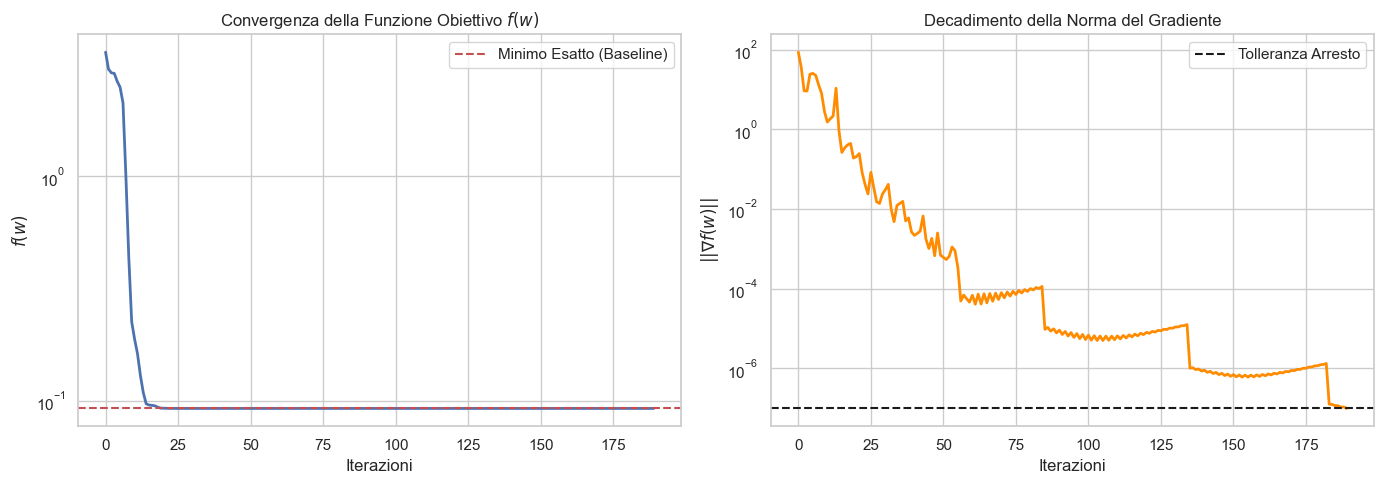

In [6]:
if __name__ == "__main__":
    # Assumiamo che X e y siano già stati generati dal tuo script di preprocessing
    # Se per caso non sono in memoria in questo notebook, usa la funzione load_and_preprocess_data per ricaricarli!

    lam_param = 0.5

    print("\n" + "="*50)
    print("1. CALCOLO BASELINE (Il bersaglio)")
    print("="*50)
    A_norm = X @ X.T + (lam_param**2) * np.eye(m)
    b_norm = X @ y
    w_baseline = np.linalg.solve(A_norm, b_norm)
    f_baseline = compute_loss(w_baseline, X, y, lam_param)
    print(f"Valore minimo ESATTO f(w*): {f_baseline:.8f}")

    print("\n" + "="*50)
    print("2. ESECUZIONE L-BFGS (A1)")
    print("="*50)
    w_opt, loss_hist, grad_hist, time_lbfgs = lbfgs_optimize(
        X, y, lam=lam_param, m_history=10, tol=1e-7, max_iter=1000
    )

    f_opt = loss_hist[-1]
    print(f"Tempo di esecuzione L-BFGS: {time_lbfgs:.4f} sec")
    print(f"Valore minimo trovato f(w): {f_opt:.8f}")

    print("\n" + "="*50)
    print("3. VERIFICA RISULTATI")
    print("="*50)

    # Errore assoluto rispetto alla baseline
    diff_f = abs(f_baseline - f_opt)
    diff_w = manual_norm(w_opt - w_baseline)

    print(f"Differenza sulla Funzione Obiettivo: {diff_f:.2e}")
    print(f"Distanza tra i pesi (w_opt vs w*):   {diff_w:.2e}")

    if diff_w < 1e-4:
        print("\n✅ SUCCESSO TOTALE! L'algoritmo L-BFGS ha trovato la soluzione matematica corretta, rispettando tutte le regole.")
    else:
        print("\n❌ Attenzione, c'è una discrepanza.")

    #
    # Grafici per il report
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(loss_hist, linewidth=2, color='b')
    plt.axhline(f_baseline, color='r', linestyle='--', label='Minimo Esatto (Baseline)')
    plt.title("Convergenza della Funzione Obiettivo $f(w)$")
    plt.xlabel("Iterazioni")
    plt.ylabel("$f(w)$")
    plt.yscale('log')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(grad_hist, linewidth=2, color='darkorange')
    plt.axhline(1e-7, color='k', linestyle='--', label='Tolleranza Arresto')
    plt.title("Decadimento della Norma del Gradiente")
    plt.xlabel("Iterazioni")
    plt.ylabel("$|| \\nabla f(w) ||$")
    plt.yscale('log')
    plt.legend()

    plt.tight_layout()
    plt.show()

## Fattorizzazione QR Thin con Riflettori di Householder